# Figure 8.

| Author  | Stanley A. Baronett  |
|---------|----------------------|
| Created |  03/04/2026          |
| Updated |  03/04/2026          |

Similar to Figure 4, except the upper panel only shows particle codes with $n_\mathrm{p} = 9$, and the lower panel shows their mean $\overline{\overline{\rho_\mathrm{d}}}$ with a dashed black curve.

In [1]:
#===============================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1 import AxesGrid
import numpy as np
import pandas as pd

res = 512
root = f'../{res}/src'
n_ps = ['np1', 'np9']
runs = {
    f'dust_particles': {
        'ls': 'dotted',
        'codes' : {
            'Athena':       'tab:green',
            'Athena++':     'tab:red',
            'Pencil':       'tab:blue',
            'PLUTO':        'tab:pink',
        }
    }
}

/tmp/ipykernel_26922/3963471058.py:55: RuntimeWarning: divide by zero encountered in log
  std = np.exp(np.std(np.log(n_p_stack), axis=0))
/home/stanley/miniconda3/envs/athena/lib/python3.11/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


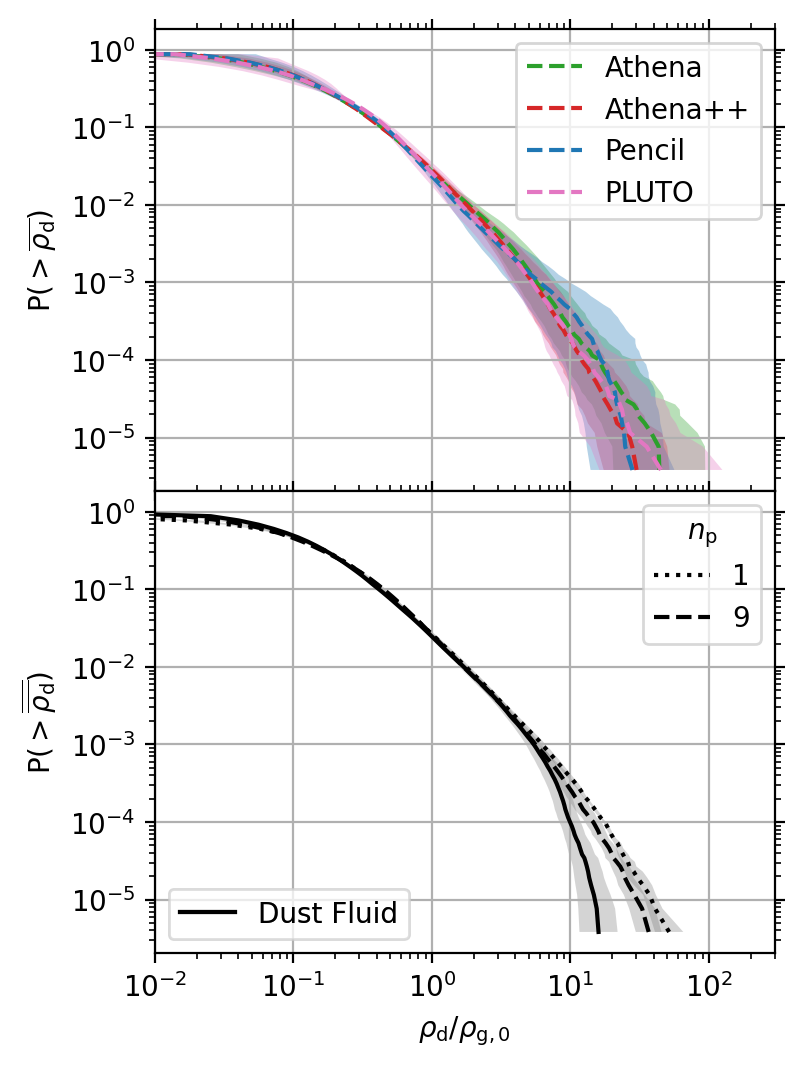

In [2]:
#===============================================================================
times = [20, 50, 100]  # [T]

runs = {
    f'dust_particles': {
        'ls': 'dotted',
        'codes' : {
            'Athena':       'tab:green',
            'Athena++':     'tab:red',
            'Pencil':       'tab:blue',
            'PLUTO':        'tab:pink',
        }
    }
}

# Plot
fig, axs = plt.subplots(nrows=2, sharex=True, figsize=(4, 6), dpi=200)
indices = -np.unique(np.logspace(np.log2(res**2), 0, num=100, base=2,
                     dtype=int))
c_handles, handles = [], []
for n_p in n_ps:
    n_p_stack = []
    for key, value in runs.items():
        for code, color in value['codes'].items():
            path = f'{root}/{key}/{n_p}/{code}'
            rhods = []
            for i, time in enumerate(times):
                snapshot = np.load(f'{path}/{time}.npz')
                sort = np.sort(snapshot['rhod'], axis=None)
                rhods.append(sort)
            rhods = np.asarray(rhods)
            avgs = np.average(rhods, axis=0)
            cdf = np.linspace(1, 0, avgs.size, endpoint=False)
            log = np.log(np.clip(rhods, 1e-45, None))
            std_log = np.std(log, axis=0)
            stds = np.clip(np.exp(std_log), None, 3)
            cdf = np.take_along_axis(cdf, indices, 0)
            avgs = np.take_along_axis(avgs, indices, 0)
            stds = np.take_along_axis(stds, indices, 0)
            if n_p == 'np1':
                alpha = 1.0
                ls = value['ls']
                hatch = None
            else:
                alpha = 1.0
                ls = 'dashed'
                c_handles.append(axs[0].plot([],[], c=color, label=code,
                                             ls=ls)[0])
                axs[0].plot(avgs, cdf, alpha=alpha, c=color, ls=ls) # fold into above?
                axs[0].fill_betweenx(cdf, avgs/stds, avgs*stds, alpha=alpha/3,
                                    color=color, ec=None)
            n_p_stack.append(avgs)
    n_p_stack = np.asarray(n_p_stack)
    mean = np.mean(n_p_stack, axis=0)
    std = np.exp(np.std(np.log(n_p_stack), axis=0))
    handles.append(axs[1].plot(mean, cdf, c='k', label=n_p[-1], ls=ls)[0])
    axs[1].fill_betweenx(cdf, mean/std, mean*std, alpha=alpha/3, color='tab:gray',
                         ec=None)
axs[1].add_artist(axs[1].legend(framealpha=0.75, handles=handles, loc='upper right',
                                title=r'$n_\mathrm{p}$'))

# Add dust fluid
runs = {
    'dust_fluid': {
        'ls': 'solid',
        'codes' : {
            'Athena++':     'tab:purple',
            'FARGO3D':      'tab:olive',
            'Idefix':       'tab:orange',
            'LA-COMPASS':   'tab:cyan',
            'PLUTO':        'tab:brown'
        }
    }
}
for key, value in runs.items():
    key_stack, handles = [], []
    for code, color in value['codes'].items():
        path = f'{root}/{key}/{code}'
        rhods = []
        for i, time in enumerate(times):
            snapshot = np.load(f'{path}/{time}.npz')
            sort = np.sort(snapshot['rhod'], axis=None)
            rhods.append(sort)
        rhods = np.asarray(rhods)
        avgs = np.average(rhods, axis=0)
        cdf = np.linspace(1, 0, avgs.size, endpoint=False)
        log = np.log(np.clip(rhods, 1e-45, None))
        std_log = np.std(log, axis=0)
        stds = np.clip(np.exp(std_log), None, 3)
        cdf = np.take_along_axis(cdf, indices, 0)
        avgs = np.take_along_axis(avgs, indices, 0)
        stds = np.take_along_axis(stds, indices, 0)
        key_stack.append(avgs)
    key_stack = np.asarray(key_stack)
    mean = np.mean(key_stack, axis=0)
    std = np.exp(np.std(np.log(key_stack), axis=0))
    handles.append(axs[1].plot(mean, cdf, c='k', label='Dust Fluid', ls=value['ls'])[0])
    axs[1].add_artist(axs[1].legend(framealpha=0.5, handles=handles, loc='lower left'))
    axs[1].fill_betweenx(cdf, mean/std, mean*std, alpha=0.33, color='tab:gray',
                         ec=None)

# Format plots
for ax in axs:
    ax.grid()
    ax.minorticks_on()
    ax.set(xscale='log', yscale='log')
    ax.tick_params(axis='both', which='both', top=True, right=True)
axs[0].legend()
axs[0].set(ylabel=r'P$(>\overline{\rho_\mathrm{d}})$')
axs[1].set(xlim=(1e-2, 3e2),
           xlabel=r'$\rho_\mathrm{d}/\rho_\mathrm{g,0}$',
           ylabel=r'P$(>\overline{\overline{\rho_\mathrm{d}}})$')
fig.subplots_adjust(hspace=0)